# TF-IDF Experiment Summary

## Initial Result

The first TF-IDF evaluation produced unexpectedly low retrieval scores:

- MAP = 0.00871
- MRR = 0.02068
- P@5 = 0.00978
- P@10 = 0.00667
- nDCG@10 = 0.00607

## Investigation

The TF-IDF results and qrels were checked for possible formatting, data-type, scoring, and query-document matching issues.

The qid and docno data types were compatible. A manual inspection of Query 1 also showed that TF-IDF was retrieving several relevant documents near the top, indicating that the TF-IDF scoring itself was working correctly.

The main issue was the query ID assignment.

The numbers after the `.I` tag in `cran.qry` were not the IDs being used to match the qrels in our setup. For example, `cran.qry` contains query identifiers such as `.I 001`, `.I 002`, `.I 004`, `.I 008`, etc., while the qrels used sequential query IDs based on the position of the query blocks.

Therefore, query IDs were reassigned according to their position in `cran.qry`:

- 1st query -> qid 1
- 2nd query -> qid 2
- 3rd query -> qid 3
- ...
- 225th query -> qid 225

The original number after the `.I` tag was therefore ignored for evaluation.

## Important Clarification

TF-IDF scores and qrel relevance labels represent different things.

TF-IDF produces numerical scores that are used to rank documents, whereas qrels contain the ground-truth relevance labels used for evaluation.

Therefore, TF-IDF scores are not expected to match the relevance grades in the qrels.

## Parameter Tuning and Model Comparison

After correcting the query ID alignment, different TF-IDF parameter settings were also tested to determine whether tuning could further improve the retrieval performance. However, the experiments showed that the default TF-IDF parameters provided the best overall results among the configurations tested.

In addition, other retrieval models were evaluated for comparison. The TF-IDF model produced better retrieval performance than the other models tested in our experiments. This indicates that TF-IDF is the most suitable retrieval approach for the current dataset and experimental setup.

Therefore, we decided to proceed with TF-IDF using its default parameters as the baseline retrieval model for the remaining experiments.

## Corrected Results

After correcting the query ID alignment, the TF-IDF evaluation improved substantially:

- MAP = 0.318897
- MRR = 0.554530
- P@5 = 0.328889
- P@10 = 0.236444
- nDCG@10 = 0.346963

The measured computational performance was:

- Index Time = approximately 3.30 seconds
- Search Time = approximately 4.25 seconds

## Final Finding

The extremely low initial evaluation scores were mainly caused by incorrect query-to-qrels ID alignment rather than a problem with TF-IDF scoring or data types.

After correcting the query IDs, the retrieval results aligned correctly with the qrels.

The corrected TF-IDF result is therefore used as the baseline for comparison with the other retrieval models and parameter settings.


Environment Setup

In [ ]:
%pip install -q python-terrier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.1/223.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.8/947.8 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.9/304.9 kB 6.9 MB/s eta 0:00:00


In [ ]:
import pyterrier as pt
import pandas as pd
import re
import time

if not pt.started():
    pt.init()

print("PyTerrier version:", pt.__version__)

/tmp/ipykernel_1307/1066108698.py:6: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():


terrier-assemblies 5.11 jar-with-dependencies not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-assemblies/5.11/terrier-assemblies-5.11-jar-with-dependenci…

Done
terrier-python-helper 0.0.8 jar not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-python-helper/0.0.8/terrier-python-helper-0.0.8.jar:   0%| …

Done
PyTerrier version: 1.1.2


Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]
/tmp/ipykernel_1307/1066108698.py:7: DeprecationWarning: Call to deprecated method pt.init(). Deprecated since version 0.11.0.
java is now started automatically with default settings. To force initialisation early, run:
pt.java.init() # optional, forces java initialisation
  pt.init()


Obtain Cranfield collection

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cran.tar.gz to cran.tar.gz


In [ ]:
import tarfile
with tarfile.open("cran.tar.gz", "r:gz") as cran:
  cran.extractall("cranfield")

/tmp/ipykernel_1307/1663252741.py:3: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  cran.extractall("cranfield")


Preprocessing of Documents

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving outliers_porter.py to outliers_porter.py
Saving outliers_preprocess.py to outliers_preprocess.py
Saving stopwords.txt to stopwords.txt


In [ ]:
import sys

sys.path.append("/content")

In [ ]:
from outliers_preprocess import (
    parse_documents,
    preprocess_text,
    load_stemmed_stopwords
)

from outliers_porter import PorterStemmer

In [ ]:
from pathlib import Path

input_path = Path("/content/cranfield/cran.all.1400")
stopwords_path = Path("/content/stopwords.txt")

In [ ]:
stemmer = PorterStemmer()
stemmed_stopwords = load_stemmed_stopwords(stopwords_path, stemmer)
documents = parse_documents(input_path)

In [ ]:
processed_documents = []

for doc_id, text in documents:
    tokens = preprocess_text(text, stemmer, stemmed_stopwords)

    processed_documents.append({
        "docno": str(doc_id),
        "text": " ".join(tokens)
    })

In [ ]:
docs = pd.DataFrame(processed_documents)
print(docs.head())

  docno                                               text
0     1  experiment investig aerodynam wing slipstream ...
1     2  simpl shear flow past flat plate incompress fl...
2     3  boundari layer simpl shear flow past flat plat...
3     4  approxim solut incompress laminar boundari lay...
4     5  dimension transient heat conduct doubl layer s...


Preprocessing of Queries

*Wrong Method*

In [ ]:
def parse_queries(file_path):

    queries = []

    with open(file_path, "r", encoding="ascii", errors="ignore") as f:
        lines = f.readlines()

    current_qid = None
    current_query = []
    in_query = False

    for line in lines:

        line = line.rstrip("\n")

        # Query ID
        match = re.match(r"\.I\s+(\d+)", line)

        if match:

            # Save previous query
            if current_qid is not None:

                queries.append({
                    "qid": str(int(current_qid)),
                    "query": " ".join(current_query).strip()
                })

            current_qid = match.group(1)
            current_query = []
            in_query = False

        elif line.strip() == ".W":

            in_query = True

        elif in_query:

            current_query.append(line.strip())

    # Save last query
    if current_qid is not None:

        queries.append({
            "qid": current_qid,
            "query": " ".join(current_query).strip()
        })

    return pd.DataFrame(queries)


*Correct Method*

In [ ]:
def parse_queries(file_path):

    queries = []

    with open(file_path, "r", encoding="ascii", errors="ignore") as f:
        lines = f.readlines()

    current_query = []
    in_query = False

    for line in lines:

        line = line.rstrip("\n")

        # Start of a new query block
        if re.match(r"\.I\s+\d+", line):

            # Save previous query
            if current_query:
                queries.append({
                    "qid": str(len(queries) + 1),
                    "query": " ".join(current_query).strip()
                })

            current_query = []
            in_query = False

        elif line.strip() == ".W":

            in_query = True

        elif in_query:

            current_query.append(line.strip())

    # Save last query
    if current_query:
        queries.append({
            "qid": str(len(queries) + 1),
            "query": " ".join(current_query).strip()
        })

    return pd.DataFrame(queries)

In [ ]:
query = parse_queries("/content/cranfield/cran.qry")

In [ ]:
processed_queries = []

for _, row in query.iterrows():

    tokens = preprocess_text(row["query"],stemmer,stemmed_stopwords)

    processed_queries.append({
        "qid": str(row["qid"]),
        "query": " ".join(tokens)
    })

query = pd.DataFrame(processed_queries)

In [ ]:
display(query.head(10))

,qid,query
0,1,similar law obey construct aeroelast model hea...
1,2,structur aeroelast problem associ flight high ...
2,3,problem heat conduct composit slab solv far
3,4,criterion develop empir valid flow solut chemi...
4,5,chemic kinet applic hyperson aerodynam problem
5,6,theoret experiment guid turbul couett flow beh...
6,7,possibl relat avail pressur distribut ogiv for...
7,8,method dash exact approxim dash present avail ...
8,9,paper intern slip flow heat transfer studi
9,10,real ga transport properti air avail wide rang...


Indexing

In [ ]:

index_path = "/content/cranfield_tfidf_index"

indexer = pt.index.IterDictIndexer(
    index_path,
    meta=["docno"],
    text_attrs=["text"],
    overwrite=True
)

In [ ]:
start_time = time.perf_counter()

indexref = indexer.index(
    docs.to_dict("records")
)

index_time = time.perf_counter() - start_time

print(f"Indexing time: {index_time:.4f} seconds")

17:27:52.176 [ForkJoinPool-1-worker-1] WARN org.terrier.structures.indexing.Indexer -- Adding an empty document to the index (471) - further warnings are suppressed
17:27:53.602 [ForkJoinPool-1-worker-1] WARN org.terrier.structures.indexing.Indexer -- Indexed 2 empty documents
Indexing time: 3.1685 seconds


In [ ]:
index = pt.IndexFactory.of(indexref)

In [ ]:
print(index.getCollectionStatistics())

Number of documents: 1400
Number of terms: 4389
Number of postings: 77353
Number of fields: 0
Number of tokens: 132181
Field names: []
Positions:   false



In [ ]:
print(index.getLexicon())

<org.terrier.structures.Lexicon at 0x7dace49549b0 jclass=org/terrier/structures/Lexicon jself=<LocalRef obj=0x5c4d482 at 0x7dace4a61e90>>


In [ ]:
lexicon = index.getLexicon()

terms = []

for entry in lexicon:
    terms.append(entry.getKey())

print("First 100 indexed terms:")
print(terms[300:350])

First 100 indexed terms:
['87', '88', '897', '899', '9', '90', '900', '9000', '91', '92', '94', '944', '95', '952', '954', '96', '962', '97', '979', '98', '981', '99', 'ab', 'abbrevi', 'abil', 'abl', 'ablat', 'abrupt', 'abruptli', 'absenc', 'absent', 'absolut', 'absorb', 'absorpt', 'abstract', 'abundantli', 'academ', 'accel', 'acceleromet', 'accentu', 'accept', 'access', 'accid', 'accommod', 'accompani', 'accomplish', 'accord', 'accordingli', 'account', 'accru']


In [ ]:
term = "aircraft"

lexicon = index.getLexicon()
entry = lexicon.getLexiconEntry(term)

if entry is None:
    print(f"'{term}' not found in index")
else:
    print("Term:", term)
    print("Document frequency:", entry.getDocumentFrequency())
    print("Collection frequency:", entry.getFrequency())

    postings = index.getInvertedIndex().getPostings(entry)

    print("\nPosting list:")
    for posting in postings:
        print(
            "docid =", posting.getId(),
            "tf =", posting.getFrequency()
        )

Term: aircraft
Document frequency: 71
Collection frequency: 157

Posting list:
docid = 11 tf = 2
docid = 13 tf = 1
docid = 28 tf = 2
docid = 46 tf = 3
docid = 50 tf = 10
docid = 74 tf = 1
docid = 75 tf = 1
docid = 77 tf = 3
docid = 99 tf = 7
docid = 171 tf = 1
docid = 183 tf = 1
docid = 194 tf = 1
docid = 201 tf = 4
docid = 208 tf = 2
docid = 219 tf = 1
docid = 236 tf = 1
docid = 244 tf = 1
docid = 250 tf = 1
docid = 252 tf = 6
docid = 310 tf = 1
docid = 327 tf = 1
docid = 344 tf = 1
docid = 363 tf = 1
docid = 373 tf = 1
docid = 414 tf = 2
docid = 415 tf = 1
docid = 452 tf = 2
docid = 496 tf = 3
docid = 657 tf = 1
docid = 720 tf = 1
docid = 723 tf = 1
docid = 724 tf = 3
docid = 725 tf = 1
docid = 728 tf = 1
docid = 746 tf = 1
docid = 790 tf = 1
docid = 791 tf = 6
docid = 803 tf = 1
docid = 809 tf = 2
docid = 810 tf = 4
docid = 835 tf = 1
docid = 877 tf = 1
docid = 881 tf = 1
docid = 882 tf = 3
docid = 883 tf = 3
docid = 907 tf = 1
docid = 908 tf = 2
docid = 910 tf = 2
docid = 913 tf = 

TF_IDF

In [ ]:
tfidf = pt.terrier.Retriever(
    index,
    wmodel="TF_IDF"
)

In [ ]:
start = time.perf_counter()

tfidf_results = tfidf.transform(query)

search_time = time.perf_counter() - start

print(f"Search time: {search_time:.4f} seconds")

Search time: 7.0513 seconds


In [ ]:
tfidf_results

,qid,query,docid,docno,rank,score
0,1,similar law obey construct aeroelast model hea...,50,51,0,17.923831
1,1,similar law obey construct aeroelast model hea...,485,486,1,17.474342
2,1,similar law obey construct aeroelast model hea...,11,12,2,15.286931
3,1,similar law obey construct aeroelast model hea...,183,184,3,14.502056
4,1,similar law obey construct aeroelast model hea...,877,878,4,13.848414
...,...,...,...,...,...,...
188970,225,design factor control lift drag ratio mach num...,836,837,891,0.782962
188971,225,design factor control lift drag ratio mach num...,1143,1144,892,0.764344
188972,225,design factor control lift drag ratio mach num...,82,83,893,0.761756
188973,225,design factor control lift drag ratio mach num...,1391,1392,894,0.751578


Evaluation

In [ ]:
qrels = pd.read_csv(
    "/content/cranfield/cranqrel",
    sep=r"\s+",
    header=None,
    names=["qid", "docno", "label"]
)

qrels["qid"] = qrels["qid"].astype(str)
qrels["docno"] = qrels["docno"].astype(str)

print(qrels.head())
print("Number of relevance judgments:", len(qrels))
print("Number of queries:", qrels["qid"].nunique())

  qid docno  label
0   1   184      2
1   1    29      2
2   1    31      2
3   1    12      3
4   1    51      3
Number of relevance judgments: 1837
Number of queries: 225


In [ ]:
print("TF-IDF columns:")
print(tfidf_results.columns.tolist())

print("\nQrels columns:")
print(qrels.columns.tolist())

TF-IDF columns:
['qid', 'query', 'docid', 'docno', 'rank', 'score']

Qrels columns:
['qid', 'docno', 'label']


In [ ]:
print(tfidf_results[["qid", "docno"]].dtypes)
print(qrels[["qid", "docno"]].dtypes)

qid      object
docno    object
dtype: object
qid      object
docno    object
dtype: object


In [ ]:
tfidf_eval = pt.Evaluate(
    tfidf_results,
    qrels,
    metrics=[
        "map",
        "recip_rank",
        "P.5",
        "P.10",
        "ndcg_cut.10"
    ]
)

In [ ]:
tfidf_results_table = pd.DataFrame([{
    "Model": "TF-IDF",
    "MAP": tfidf_eval["map"],
    "MRR": tfidf_eval["recip_rank"],
    "P@5": tfidf_eval["P.5"],
    "P@10": tfidf_eval["P.10"],
    "nDCG@10": tfidf_eval["ndcg_cut.10"],
    "Index Time (s)": index_time,
    "Search Time (s)": search_time
}])

tfidf_results_table

,Model,MAP,MRR,P@5,P@10,nDCG@10,Index Time (s),Search Time (s)
0,TF-IDF,0.318897,0.55453,0.328889,0.236444,0.346963,4.632597,7.05132


What is the Issue?

In [ ]:
tfidf_pairs = set(
    zip(tfidf_results["qid"], tfidf_results["docno"])
)

qrel_pairs = set(
    zip(qrels["qid"], qrels["docno"])
)

overlap = tfidf_pairs & qrel_pairs

print("TF-IDF pairs:", len(tfidf_pairs))
print("Qrels pairs:", len(qrel_pairs))
print("Matching pairs:", len(overlap))

TF-IDF pairs: 188975
Qrels pairs: 1837
Matching pairs: 779


In [ ]:
print("TF-IDF queries:", tfidf_results["qid"].nunique())
print("Qrel queries:", qrels["qid"].nunique())

TF-IDF queries: 225
Qrel queries: 225


In [ ]:
print("TF-IDF top 20 for query 001")

display(
    tfidf_results[
        tfidf_results["qid"] == 1
    ][
        ["qid", "docno", "rank", "score"]
    ].head(20)
)

TF-IDF top 20 for query 001


,qid,docno,rank,score


In [ ]:
print(tfidf_results["qid"].unique()[:20])
print(qrels["qid"].unique()[:20])

['1' '2' '4' '8' '9' '10' '12' '13' '15' '18' '22' '23' '26' '27' '29'
 '31' '32' '33' '34' '35']
['1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15' '16'
 '17' '18' '19' '20']


In [ ]:
print(query["qid"].unique()[:30])

['1' '2' '4' '8' '9' '10' '12' '13' '15' '18' '22' '23' '26' '27' '29'
 '31' '32' '33' '34' '35' '39' '40' '41' '49' '50' '51' '52' '53' '54'
 '55']


In [ ]:
print("Number of queries:", query["qid"].nunique())
print("Number of qrel queries:", qrels["qid"].nunique())

print("\nQueries in qrels but NOT in query file:")
print(sorted(
    set(qrels["qid"]) - set(query["qid"]),
    key=int
))

Number of queries: 225
Number of qrel queries: 225

Queries in qrels but NOT in query file:
['3', '5', '6', '7', '11', '14', '16', '17', '19', '20', '21', '24', '25', '28', '30', '36', '37', '38', '42', '43', '44', '45', '46', '47', '48', '60', '63', '64', '65', '70', '73', '75', '76', '77', '78', '88', '89', '90', '91', '92', '96', '115', '117', '124', '125', '127', '129', '134', '144', '151', '159', '162', '166', '172', '174', '178', '179', '180', '185', '186', '188', '191', '192', '193', '194', '195', '197', '198', '199', '207', '220', '221', '222']


In [ ]:
display(qrels[qrels["qid"] == "1"])

,qid,docno,label
0,1,184,2
1,1,29,2
2,1,31,2
3,1,12,3
4,1,51,3
5,1,102,3
6,1,13,4
7,1,14,4
8,1,15,4
9,1,57,2


In [ ]:
display(
    tfidf_results[
        tfidf_results["qid"] == "1"
    ][["qid", "docno", "rank", "score"]].head(20)
)

,qid,docno,rank,score
0,1,51,0,17.923831
1,1,486,1,17.474342
2,1,12,2,15.286931
3,1,184,3,14.502056
4,1,878,4,13.848414
5,1,746,5,11.715651
6,1,665,6,11.576917
7,1,573,7,11.029298
8,1,141,8,10.804197
9,1,78,9,10.266528


In [ ]:
print(qrels["label"].unique())

[ 2  3  4 -1  1]


Fine Tuning TF_IDF

*Find Parameters*

In [ ]:
help(pt.terrier.Retriever)

Help on class Retriever in module pyterrier.terrier.retriever:

class Retriever(pyterrier.transformer.Transformer)
 |  Retriever(
 |      index_location: Union[str, Any],
 |      controls: Optional[Dict[str, str]] = None,
 |      properties: Optional[Dict[str, str]] = None,
 |      metadata: List[str] = ['docno'],
 |      num_results: Optional[int] = None,
 |      wmodel: Union[str, Callable, NoneType] = None,
 |      tokeniser: Union[str, pyterrier.terrier.tokeniser.TerrierTokeniser] = <TerrierTokeniser.english: 'english'>,
 |      threads: int = 1,
 |      verbose: bool = False
 |  )
 |
 |  Use this class for retrieval by Terrier
 |
 |  Method resolution order:
 |      Retriever
 |      pyterrier.transformer.Transformer
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __eq__(self, other)
 |      Return self==value.
 |
 |  __getstate__(self)
 |      Helper for pickle.
 |
 |  __hash__(self)
 |      Return hash(self).
 |
 |  __init__(
 |      self,
 |      index_location: Uni

In [ ]:
print(pt.terrier.Retriever.__doc__)
import pyterrier.terrier as pt_terrier
import inspect

print(inspect.getsource(pt.terrier.Retriever))


Use this class for retrieval by Terrier

@pt.java.required
class Retriever(pt.Transformer):
    """
    Use this class for retrieval by Terrier
    """

    @staticmethod
    def matchop(t, w=1):
        """
        Static method used for rewriting a query term to use a MatchOp operator if it contains
        anything except ASCII letters or digits.
        """
        import base64
        import string
        if not all(a in string.ascii_letters + string.digits for a in t):
            encoded = base64.b64encode(t.encode('utf-8')).decode("utf-8") 
            t = f'#base64({encoded})'
        if w != 1:
            t = f'#combine:0={w}({t})'
        return t


    @staticmethod
    def from_dataset(dataset : Union[str,Dataset], 
            variant : Optional[str] = None, 
            version='latest',            
            **kwargs):
        """
        Static method that instantiates a Retriever object from a pre-built index access via a dataset.
        Pre-built indices are o

In [ ]:
import pyterrier as pt
if not pt.java.started():
    pt.java.init()

from jnius import autoclass

# Load and instantiate the Java class
ModelClass = autoclass("org.terrier.matching.models.TF_IDF")
instance = ModelClass()

# Get the real java.lang.Class object via the instance, THEN reflect on it
java_class = instance.getClass()

print("Methods:")
for method in java_class.getDeclaredMethods():
    print(" ", method.getName())

print("\nFields:")
for field in java_class.getDeclaredFields():
    print(" ", field.getName())

terrier-assemblies 5.11 jar-with-dependencies not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-assemblies/5.11/terrier-assemblies-5.11-jar-with-dependenci…

Done
terrier-python-helper 0.0.8 jar not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-python-helper/0.0.8/terrier-python-helper-0.0.8.jar:   0%| …

Done
Methods:
  score
  setParameter
  getParameter
  prepare
  getInfo

Fields:
  serialVersionUID
  name
  k_1
  b


Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]


In [ ]:
from jnius import autoclass

TFIDF = autoclass("org.terrier.matching.models.TF_IDF")
Modifier = autoclass("java.lang.reflect.Modifier")

model = TFIDF()
java_class = model.getClass()

print("Class:", java_class)

print("\nFields:")
for field in java_class.getDeclaredFields():
    modifiers = field.getModifiers()

    print(
        field.getName(),
        "| type =", field.getType(),
        "| public =", Modifier.isPublic(modifiers),
        "| private =", Modifier.isPrivate(modifiers),
        "| protected =", Modifier.isProtected(modifiers)
    )

print("\nCurrent values:")
print("k1 =", model.k_1)
print("b  =", model.b)


Class: Class: org.terrier.matching.models.TF_IDF

Fields:
serialVersionUID | type = Primitive: long | public = False | private = True | protected = False
name | type = Class: java.lang.String | public = False | private = True | protected = False
k_1 | type = Primitive: double | public = False | private = True | protected = False
b | type = Primitive: double | public = False | private = True | protected = False

Current values:
k1 = 1.2
b  = 0.75


In [ ]:
print("Default parameter:", model.getParameter())
model.setParameter(2.0)
print("After setParameter:", model.getParameter())
print("k1:", model.k_1)
print("b:", model.b)

Default parameter: 0.75
After setParameter: 2.0
k1: 1.2
b: 2.0


*Method-1*

In [ ]:
from jnius import autoclass

TFIDF = autoclass("org.terrier.matching.models.TF_IDF")

systems = []

for b in [0.0, 0.25, 0.5, 0.75, 1.0]:

    model = TFIDF()
    model.setParameter(b)

    retriever = pt.terrier.Retriever(
        index,
        wmodel=model
    )

    systems.append(retriever)


In [ ]:
experiment = pt.Experiment(
    systems,
    query,
    qrels,
    eval_metrics=["map", "recip_rank", "P.5", "P.10", "ndcg_cut.10"],
    names=[
        "TF_IDF_b=0.0",
        "TF_IDF_b=0.25",
        "TF_IDF_b=0.5",
        "TF_IDF_b=0.75",
        "TF_IDF_b=1.0"
    ]
)

print(experiment)


            name       map  recip_rank       P.5      P.10  ndcg_cut.10
0   TF_IDF_b=0.0  0.295380    0.536565  0.303111  0.215111     0.326271
1  TF_IDF_b=0.25  0.307843    0.540591  0.318222  0.229778     0.339938
2   TF_IDF_b=0.5  0.313424    0.549841  0.333333  0.236000     0.345098
3  TF_IDF_b=0.75  0.318897    0.554530  0.328889  0.236444     0.346963
4   TF_IDF_b=1.0  0.315392    0.548884  0.327111  0.236000     0.342755


*Method-2*

In [ ]:
c_values = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5, 3.0]

results = []

for c in c_values:
    tfidf = pt.terrier.Retriever(
        index,
        wmodel="TF_IDF",
        controls={"c": str(c)}
    )

    start = time.perf_counter()
    tfidf_results = tfidf.transform(query)
    search_time = time.perf_counter() - start

    evaluation = pt.Evaluate(
        tfidf_results,
        qrels,
        metrics=["map", "recip_rank", "P.5", "P.10", "ndcg_cut.10"]
    )

    results.append({
        "c": c,
        "MAP": evaluation["map"],
        "MRR": evaluation["recip_rank"],
        "P@5": evaluation["P.5"],
        "P@10": evaluation["P.10"],
        "nDCG@10": evaluation["ndcg_cut.10"],
        "Index Time (s)": index_time,
        "Search Time (s)": search_time
    })

results_df = pd.DataFrame(results).sort_values(by="MAP", ascending=False)
results_df

,c,MAP,MRR,P@5,P@10,nDCG@10,Index Time (s),Search Time (s)
3,0.75,0.318897,0.554530,0.328889,0.236444,0.346963,4.632597,5.404418
4,1.00,0.315392,0.548884,0.327111,0.236000,0.342755,4.632597,4.952189
2,0.50,0.313424,0.549841,0.333333,0.236000,0.345098,4.632597,4.639499
1,0.25,0.307843,0.540591,0.318222,0.229778,0.339938,4.632597,5.947974
5,1.50,0.297823,0.512140,0.298667,0.227556,0.327203,4.632597,4.604225
0,0.00,0.295380,0.536565,0.303111,0.215111,0.326271,4.632597,4.647581
6,2.00,0.242940,0.432164,0.232889,0.191556,0.268586,4.632597,5.900122
7,2.50,0.102258,0.132022,0.056889,0.078222,0.082179,4.632597,4.493199
8,3.00,0.076725,0.114279,0.030222,0.043111,0.047978,4.632597,5.937273


In [ ]:
best = results_df.iloc[0]

In [ ]:
best

,3
c,0.750000
MAP,0.318897
MRR,0.554530
P@5,0.328889
P@10,0.236444
nDCG@10,0.346963
Index Time (s),4.632597
Search Time (s),5.404418


*Method-3*

It Doesn't Work... only can pass one parameter

In [ ]:
k1_values = [0.4, 0.8, 1.2, 1.6, 2.0]
b_values = [0.0, 0.25, 0.5, 0.75, 1.0]

results = []

for k1 in k1_values:

    for b in b_values:

        tfidf = pt.terrier.Retriever(
            index,
            wmodel="TF_IDF",
            controls={
                "TF_IDF.k_1": str(k1),
                "TF_IDF.b": str(b)
            }
        )

        start = time.perf_counter()
        tfidf_results = tfidf.transform(query)
        search_time = time.perf_counter() - start

        evaluation = pt.Evaluate(
            tfidf_results,
            qrels,
            metrics=["map", "recip_rank", "P.5", "P.10", "ndcg_cut.10"]
        )

        results.append({
            "k1": k1,
            "b" : b,
            "MAP": evaluation["map"],
            "MRR": evaluation["recip_rank"],
            "P@5": evaluation["P.5"],
            "P@10": evaluation["P.10"],
            "nDCG@10": evaluation["ndcg_cut.10"],
            "Index Time (s)": index_time,
            "Search Time (s)": search_time
        })

results_df = pd.DataFrame(results).sort_values(by="MAP", ascending=False)
results_df

,k1,b,MAP,MRR,P@5,P@10,nDCG@10,Index Time (s),Search Time (s)
0,0.4,0.00,0.318897,0.55453,0.328889,0.236444,0.346963,3.168535,5.694621
1,0.4,0.25,0.318897,0.55453,0.328889,0.236444,0.346963,3.168535,4.608215
2,0.4,0.50,0.318897,0.55453,0.328889,0.236444,0.346963,3.168535,4.906150
3,0.4,0.75,0.318897,0.55453,0.328889,0.236444,0.346963,3.168535,4.746145
4,0.4,1.00,0.318897,0.55453,0.328889,0.236444,0.346963,3.168535,4.186521
5,0.8,0.00,0.318897,0.55453,0.328889,0.236444,0.346963,3.168535,5.354830
6,0.8,0.25,0.318897,0.55453,0.328889,0.236444,0.346963,3.168535,4.230042
7,0.8,0.50,0.318897,0.55453,0.328889,0.236444,0.346963,3.168535,4.936140
8,0.8,0.75,0.318897,0.55453,0.328889,0.236444,0.346963,3.168535,4.459151
9,0.8,1.00,0.318897,0.55453,0.328889,0.236444,0.346963,3.168535,4.245203


Visualize

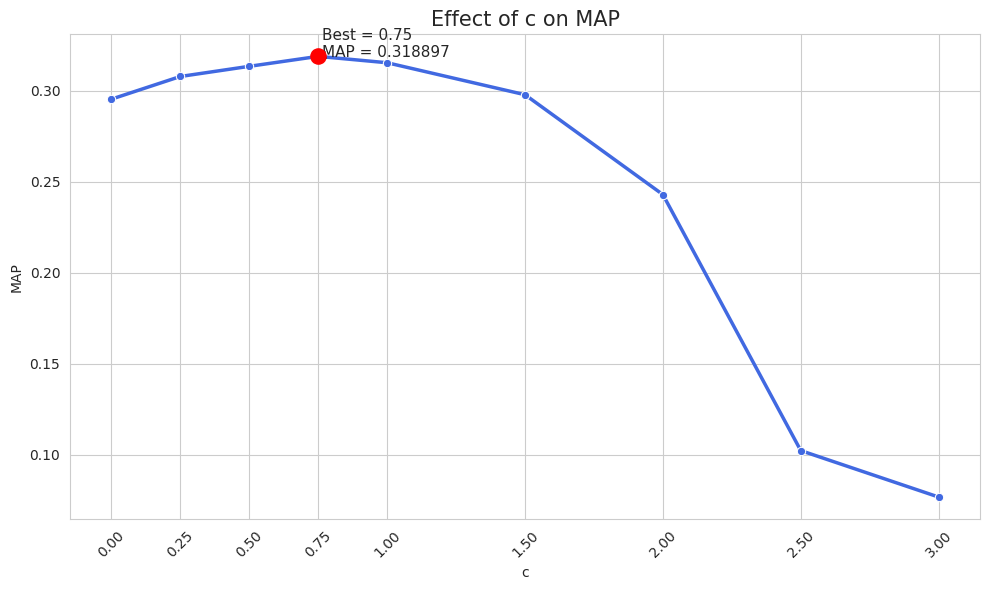

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=results_df,
    x="c",
    y="MAP",
    marker="o",
    linewidth=2.5,
    color="royalblue"
)

# Find best MAP
best_idx = results_df["MAP"].idxmax()
best_weight = results_df.loc[best_idx, "c"]
best_map = results_df.loc[best_idx, "MAP"]

# Highlight best point
plt.scatter(
    best_weight,
    best_map,
    color="red",
    s=120,
    zorder=5
)

plt.annotate(
    f"Best = {best_weight:.2f}\nMAP = {best_map:.6f}",
    xy=(best_weight, best_map),
    xytext=(best_weight + 0.015, best_map - 0.0005),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=11
)

plt.title("Effect of c on MAP", fontsize=15)
plt.xlabel("c")
plt.ylabel("MAP")
plt.xticks(results_df["c"], rotation=45)
plt.tight_layout()
plt.show()


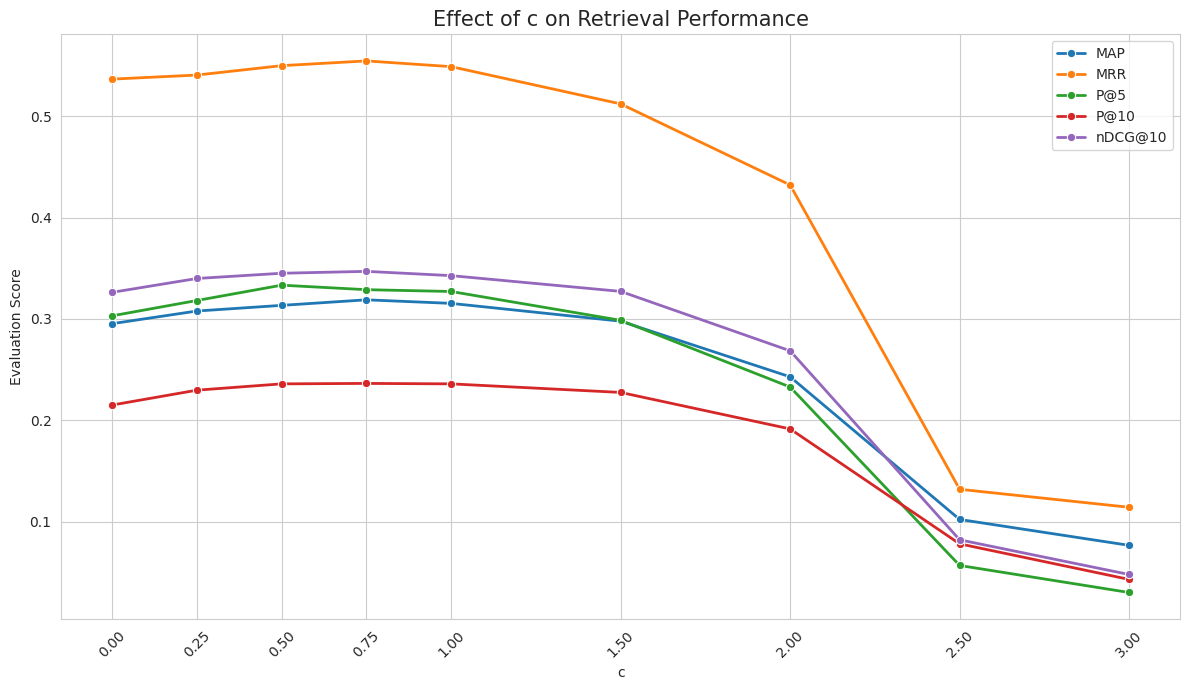

In [ ]:
metrics = ["MAP", "MRR", "P@5", "P@10", "nDCG@10"]

plt.figure(figsize=(12, 7))

for metric in metrics:
    sns.lineplot(
        data=results_df,
        x="c",
        y=metric,
        marker="o",
        linewidth=2,
        label=metric
    )

plt.title(
    "Effect of c on Retrieval Performance",
    fontsize=15
)

plt.xlabel("c")
plt.ylabel("Evaluation Score")

plt.xticks(
    results_df["c"],
    rotation=45
)

plt.legend()
plt.tight_layout()
plt.show()


Comparison on TF, TF IDF and Lemur TF IDF

In [ ]:
tfidf = pt.terrier.Retriever(
    index,
    wmodel="TF_IDF"
)

tf = pt.terrier.Retriever(
    index,
    wmodel="Tf"
)

lemur_tf = pt.terrier.Retriever(
    index,
    wmodel="LemurTF_IDF"
)

systems = [
    tfidf,
    tf,
    lemur_tf
]

experiment = pt.Experiment(
    systems,
    query,
    qrels,
    eval_metrics=[
        "map",
        "recip_rank",
        "P.5",
        "P.10",
        "ndcg_cut.10"
    ],
    names=[
        "TF_IDF",
        "TF",
        "LemurTF"
    ]
)

print(experiment)


      name       map  recip_rank       P.5      P.10  ndcg_cut.10
0   TF_IDF  0.318897    0.554530  0.328889  0.236444     0.346963
1       TF  0.193439    0.429683  0.194667  0.151556     0.223466
2  LemurTF  0.294497    0.512934  0.297778  0.227556     0.323470
